# Background subtraction using polynomial or Gaussian fitting

The cell below will demonstrate background subtraction using polynomial fitting. You can also choose Gaussian fitting by setting `baseline_method='gaussian'`.

Ways to specify the `baseline_method` parameter:

```python   
# options set in v0.2.4 and earlier versions, only polynomial and gaussian fitting is available
# String shorthand
PLfit(..., background_remove=True, baseline_method="poly", poly_degree=1)

# Tuple shorthand
PLfit(..., background_remove=True, baseline_method=("poly", 1))
PLfit(..., background_remove=True, baseline_method=("gaussian", 10))

# Dict explicit
PLfit(..., background_remove=True, baseline_method={"method": "poly", "poly_degree": 1})
PLfit(..., background_remove=True, baseline_method={"method": "gaussian", "gaussian_sigma": 10})
```

## Legacy style with `airpls` method for background subtraction

The next cell will demonstrate background subtraction using `airpls` method (a.k.a. "adaptive iteratively reweighted penalized least squares"). This method is more advanced and generally provides better baseline correction for PL spectra. This method is particularly effective for spectra with varying baseline shapes and work best if you have strong peaks on top of baseline.

**Suggested tuning:**

- If baseline remains too high near peaks: increase niter (e.g., 100) and/or decrease tol

- If the baseline becomes unstable: increase lam

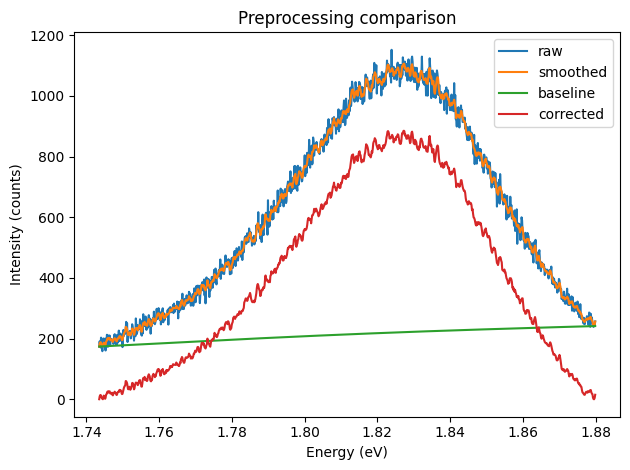

Normalized Residual: 0.0009 (Perfect fit has R = 0)

Per-peak (pseudo-Voigt): position, FWHM, eta, peak height:
Trion: 1.81 eV | FWHM: 0.06 eV  | Peak height: 492.65 | eta: 0.01
Exciton: 1.84 eV | FWHM: 0.05 eV  | Peak height: 529.60 | eta: 0.01


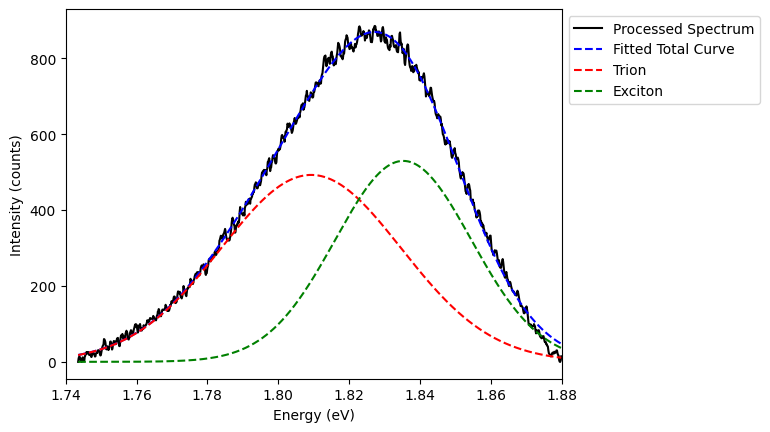

In [1]:
from ramanpl import PLfit

# Import data from WDF file
intensity, energy = PLfit.DataImporter.data_import(
    filename='PL Sample MoS2 2D Flakes.wdf',
    x_range=(1.74, 1.88)
)

# Instantiate the PLfit class with the PL data
pl_fit = PLfit.PLfit(
    intensity, energy,
    background_remove=True,
    baseline_method={"method": "airpls", "lam": 1e6, "niter": 50, "tol": 1e-6},
    smoothing=True, smooth_window=8,
    normalize=False,
    # Set peak_profile to "pvoigt" to switch model
    peak_profile="pvoigt",
                     )

# Update bounds, notice that pvoigt require *4* parameters, as last one is eta
pl_fit.update_bounds(
    exciton=([1.82, 1e-4, 0, 0.01], [1.88, 0.08, 0.1, 0.99]),
    trion=  ([1.80, 1e-4, 0, 0.01], [1.86, 0.12, 0.1, 1.0]),
)

# Perform fitting
params, params_cov = pl_fit.fit_spectrum()

# Plot the results with optional offset and scale
pl_fit.plot_fit(params,             # the parameters fitted by fit_spectrum
                offset=0,           # Offset of fitted-curve to raw data 
                scale=1,            # Intensity multiply scale for plotting 
                x_lim=[1.74,1.88]   # x-axis limit for plotting, unit: eV
                )

## Piple-line for background subtraction and smoothing

Now use this one pipeline for multiple spectra collected under the same experimental setting, and the pipeline will be automatically applied to all spectra when you instantiate `PLfit` with the pipeline object.

```python
from ramanpl.preprocessing import Pipeline, SmoothSavGol, BaselineSubtract 
pl_pipe = Pipeline(
    steps=[
        SmoothSavGol(window_length=7, polyorder=2),
        BaselineSubtract(method="poly", poly_degree=1)
    ]
)
```

*To be updated* more details on how to build pipelines and the available steps in the `preprocessing` module. This will be covered in the documentation in the near future, but for now you can refer to the docstrings in `preprocessing.py` for details on the available steps and their parameters.
 
First, you need to build a standard `Pipeline` object:

In [2]:
from ramanpl.preprocessing import Pipeline, SmoothSavGol, BaselineSubtract, CropByRange

pl_pipe = Pipeline(
    steps=[
        CropByRange((1.74, 1.88)),  # Select data in the specified energy range
        SmoothSavGol(window_length=9, polyorder=3),
        BaselineSubtract(
            baseline_spec={"method": "airpls", "lam": 1e6, "niter": 50, "tol": 1e-6}
        ),
    ],
    name="standard_pl_pipeline",
)

Now you can instantiate `PLfit` using the pipeline and do the fitting as usual. The pipeline will be automatically applied to all spectra before fitting.

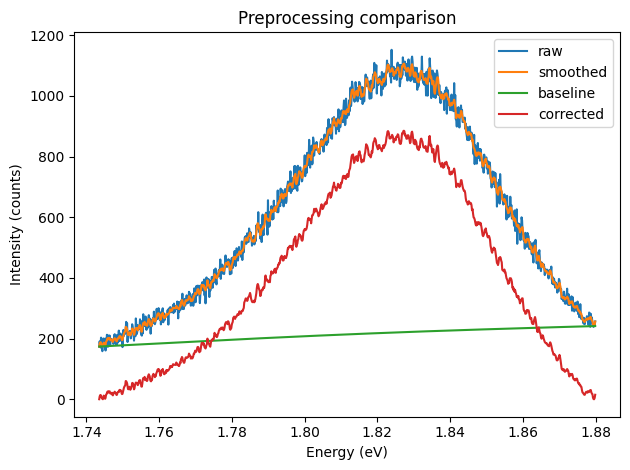

Normalized Residual: 0.0067 (Perfect fit has R = 0)

Per-peak (Lorentzian): position, FWHM, peak height:
Trion: 1.812 eV | FWHM: 0.0436 eV | Peak height: 591.30
Exciton: 1.836 eV | FWHM: 0.0334 eV | Peak height: 578.19


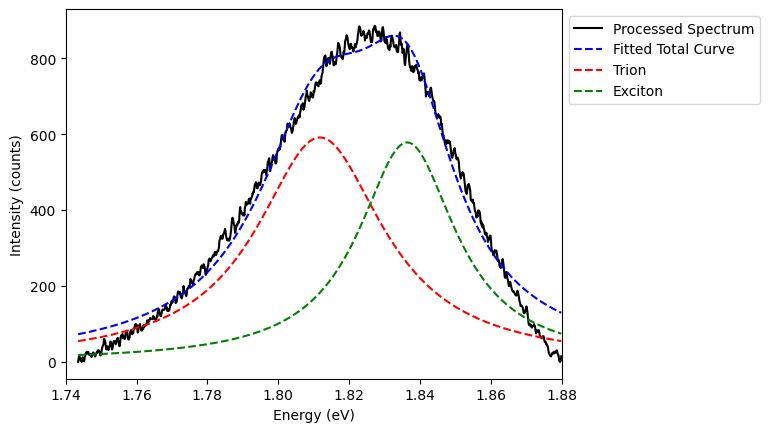

In [3]:
from ramanpl import PLfit
from ramanpl.dataImporter import DataImporter

intensity, energy = DataImporter.data_import(
    filename="PL Sample MoS2 2D Flakes.wdf",
    axis="energy",
)

pl_fit = PLfit.PLfit(
    intensity, energy,
    normalize=False,

    ## Key steps:
    preprocessing=pl_pipe,
)

pl_fit.update_bounds(
    exciton=([1.82, 0, 0], [1.88, 0.05, 0.1]),
    trion=  ([1.80, 0, 0], [1.86, 0.05, 0.05]),
)

params, cov = pl_fit.fit_spectrum()
pl_fit.plot_fit(params, x_lim=[1.74, 1.88])

Now you can apply the same standard pre-processing pipeline to multiple spectra collected under the same experimental setting, and the pipeline will be automatically applied to all spectra when you instantiate `PLfit` with the pipeline object.

```python
# spectrum 1
intensity1, energy1 = DataImporter.data_import(
    filename="PL Sample 1.wdf",
    x_range=(1.74, 1.88),
    axis="energy",
)
fit1 = PLfit.PLfit(intensity1, energy1, preprocessing=pl_pipe)

# spectrum 2
intensity2, energy2 = DataImporter.data_import(
    filename="PL Sample 2.wdf",
    x_range=(1.74, 1.88),
    axis="energy",
)
fit2 = PLfit.PLfit(intensity2, energy2, preprocessing=pl_pipe)
```